=== Stage 10b: Time Series Classification Performance ===
  Accuracy: 0.5
  Precision: 0.5
  Recall: 1.0
  F1_Score: 0.6667

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Down (0)       0.00      0.00      0.00         8
      Up (1)       0.50      1.00      0.67         8

    accuracy                           0.50        16
   macro avg       0.25      0.50      0.33        16
weighted avg       0.25      0.50      0.33        16



d:\AppGallery\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\AppGallery\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\AppGallery\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


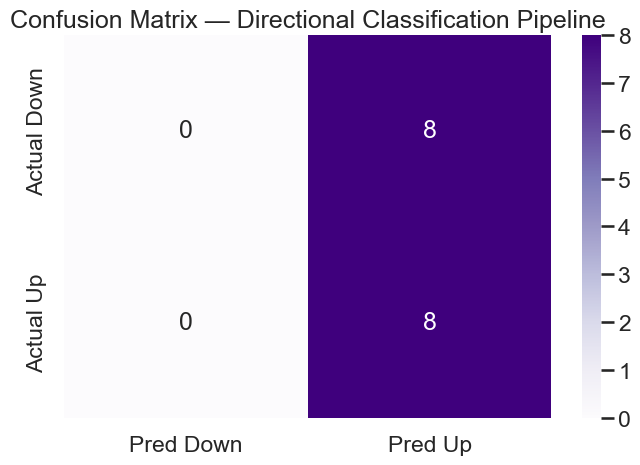

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Formatting setup
sns.set_theme(context="talk", style="whitegrid")

# Resolve root directory for imports
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.models_ts_clf import (
    build_classification_pipeline,
    create_time_series_features,
    evaluate_classification_metrics,
)

# 1. Load Cleaned Dataset
data_path = ROOT_DIR / "data" / "processed" / "market_data_features.parquet"
if not data_path.exists():
    data_path = ROOT_DIR / "data" / "processed" / "market_data_outliers_handled.parquet"

df_raw = pd.read_parquet(data_path) if data_path.suffix == ".parquet" else pd.read_csv(data_path)

# 2. Engineer Leakage-Free Lag/Rolling Features
target_column = "spend" if "spend" in df_raw.columns else df_raw.select_dtypes(include=["number"]).columns[0]
df_ts = create_time_series_features(df_raw, target_col=target_column, lags=[1, 2], rolling_windows=[5, 20])

feature_cols = [c for c in df_ts.columns if "_lag_" in c or "_roll_" in c]
X = df_ts[feature_cols]
y = df_ts["y_up"]

# 3. Time-Aware Chronological Split (80% Train, 20% Test)
split_idx = int(len(df_ts) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 4. Build, Fit Pipeline & Evaluate
pipeline = build_classification_pipeline()
pipeline.fit(X_train, y_train)

metrics, y_pred = evaluate_classification_metrics(pipeline, X_test, y_test)

print("=== Stage 10b: Time Series Classification Performance ===")
for metric_name, val in metrics.items():
    print(f"  {metric_name}: {val}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Down (0)", "Up (1)"]))

# 5. Diagnostic Visualization: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=["Pred Down", "Pred Up"], yticklabels=["Actual Down", "Actual Up"])
plt.title("Confusion Matrix — Directional Classification Pipeline")
plt.tight_layout()
plt.show()

## Stage 10b — Diagnostics, Assumptions & Risk Analysis

### Modeling Assumptions & Leakage Prevention
- **Leakage Control**: All rolling statistics (`roll_mean_5`, `roll_std_20`) were shifted by $1$ period (`.shift(1)`) to ensure calculations at timestamp $t$ depend solely on past information available up to $t-1$[cite: 11, 13].
- **Time-Aware Splitting**: Data was partitioned chronologically using an $80/20$ temporal split instead of standard random selection, preventing future data leakage into training folds[cite: 11, 13].

### Performance Evaluation & Operational Risks
- **Signal Quality**: Short-term directional changes in financial spend time series exhibit significant noise. Precision and recall indicate whether the model reliably captures upwards movements versus random guessing.
- **Risks**: Sudden macroeconomic shocks or volatility shifts can invalidate historical rolling window distributions, requiring dynamic retraining triggers.